<a href="https://colab.research.google.com/github/AkemjotSingh/csot-ml-astronomy-akemjotsingh/blob/main/week3_cnn_starter_akemjotsingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 3 . Part 1: A CNN and the Training Loop (Starter)

**Goal:** Replace the Week-2 MLP with a **Convolutional Neural Network**, then write the **training loop** that teaches it. By the end you'll watch the training loss fall over several epochs.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). This week it actually matters for speed.
2. Read [`01-convolutions-and-pooling.md`](../01-convolutions-and-pooling.md), [`02-building-a-cnn.md`](../02-building-a-cnn.md), and [`03-the-training-loop.md`](../03-the-training-loop.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Re-create the Week 1 data pipeline

Week 3 builds directly on the `DataLoader`s from Week 1. Paste that pipeline below (download is commented out in the Week-1 solution - uncomment it the first time). If you saved `galaxy_data/` to Google Drive in Week 1, re-mount Drive and point `ImageFolder` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [14]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [5]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
#   print("classes:", train_ds.classes, "num_classes:", num_classes)
from google.colab import files

files.upload()

os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

!pip install kaggle -q
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q galaxy-zoo-2-images.zip -d galaxy_raw

!wget -q "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz" -O galaxy_raw/gz2_hart16.csv.gz
!gunzip galaxy_raw/gz2_hart16.csv.gz

RAW_ROOT   = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT  = Path("galaxy_data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [03:04<00:00, 17.8MB/s]



In [15]:
def high_level_label(gz2_class):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, ...) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    return df.dropna(subset=["label"]).reset_index(drop=True)


def _link_image(src, dst):
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(images_dir, df, out_root, per_class=200,
                                   train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    images_dir, out_root = Path(images_dir), Path(out_root)
    summary = {}
    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)
        n = len(rows)
        n_train = int(train_frac * n); n_val = int(val_frac * n)
        splits = {"train": rows.iloc[:n_train],
                  "val": rows.iloc[n_train:n_train + n_val],
                  "test": rows.iloc[n_train + n_val:]}
        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary
df = load_labeled_table(RAW_ROOT / "gz2_filename_mapping.csv", RAW_ROOT / "gz2_hart16.csv")
build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=200)
print("layout built")

layout built


In [16]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes:", train_ds.classes, "| num_classes:", num_classes)

classes: ['elliptical', 'spiral', 'spiral_barred'] | num_classes: 3


## Step 1 - Define the CNN

Two `Conv -> ReLU -> Pool` blocks (channels `3 -> 16 -> 32`, each conv `kernel_size=3, padding=1`), then a `Flatten -> Linear -> ReLU -> Linear` head. With a 64x64 input and two 2x2 pools, the feature maps are `(B, 32, 16, 16)`, so the flattened size is `32*16*16 = 8192`. The final layer returns **raw logits** (no softmax). Don't forget `super().__init__()`.

In [17]:
# TODO: define GalaxyCNN(nn.Module).
#   features = nn.Sequential(
#       nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#       nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
#   classifier = nn.Sequential(
#       nn.Flatten(), nn.Linear(32*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))
#   forward(x): x = features(x); x = classifier(x); return x
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()                                  # MUST be first
        # --- Feature extractor: two Conv -> ReLU -> Pool blocks ---
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),     # (B, 16, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2),                                 # (B, 16, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),    # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                                 # (B, 32, 16, 16)
        )
        # --- Classifier head ---
        self.classifier = nn.Sequential(
            nn.Flatten(),                                    # (B, 8192)
            nn.Linear(32 * 16 * 16, 128),                    # (B, 128)
            nn.ReLU(),
            nn.Linear(128, num_classes),                     # (B, num_classes) logits
        )

    def forward(self, x):                                    # x: (B, 3, 64, 64)
        x = self.features(x)                                 # (B, 32, 16, 16)
        x = self.classifier(x)                               # (B, num_classes)
        return x

## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [18]:
# TODO: model = GalaxyCNN(num_classes=num_classes).to(device)
#       print(model)
model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 - Forward-pass one real batch and count parameters

Pull a batch from `train_loader`, move it to the device, and confirm the output is `(batch_size, num_classes)`. Then print the parameter count - notice the convolutions are tiny and the first `Linear` dominates (compare with the Week-2 MLP's ~1.57M first layer).

In [19]:
# TODO: images, labels = next(iter(train_loader)); move both to device.
#       logits = model(images); print(logits.shape)  # expect (B, num_classes)
#       total = sum(p.numel() for p in model.parameters()); print(f"params: {total:,}")
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
logits = model(images)
print("logits shape:", logits.shape)   # expect (B, num_classes)

total = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total:,}")

logits shape: torch.Size([32, 3])
total parameters: 1,054,179


## Step 4 - Loss, optimiser, and a starting-loss sanity check

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default. An untrained model on `C` balanced classes should give a loss near `ln(C)`.

In [20]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = optim.Adam(model.parameters(), lr=1e-3)
#       loss = criterion(logits, labels); print(loss.item(), "vs ln(C) =", math.log(num_classes))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

start_loss = criterion(logits, labels).item()
print(f"untrained loss: {start_loss:.4f}  (expected near ln({num_classes}) = {math.log(num_classes):.4f})")

untrained loss: 1.0989  (expected near ln(3) = 1.0986)


## Step 5 - The training loop

For each epoch, loop over `train_loader` and run the **five steps** every batch: `zero_grad -> forward -> loss -> backward -> step`. Accumulate a running loss and store the epoch average in `train_losses`. Call `model.train()` at the start of each epoch and `.to(device)` every batch.

In [21]:
num_epochs = 8
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()              # 1
        outputs = model(inputs)            # 2
        loss = criterion(outputs, targets) # 3
        loss.backward()                    # 4
        optimizer.step()                   # 5
        running += loss.item() * inputs.size(0)
    epoch_loss = running / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

Epoch  1/8  train loss: 1.1661
Epoch  2/8  train loss: 1.1093
Epoch  3/8  train loss: 1.0967
Epoch  4/8  train loss: 1.0802
Epoch  5/8  train loss: 1.0499
Epoch  6/8  train loss: 1.0260
Epoch  7/8  train loss: 0.9835
Epoch  8/8  train loss: 0.9767


## Step 6 - Plot the loss curve

A healthy run shows `train_losses` trending **down**. Small wiggles are fine; the trend is what matters.

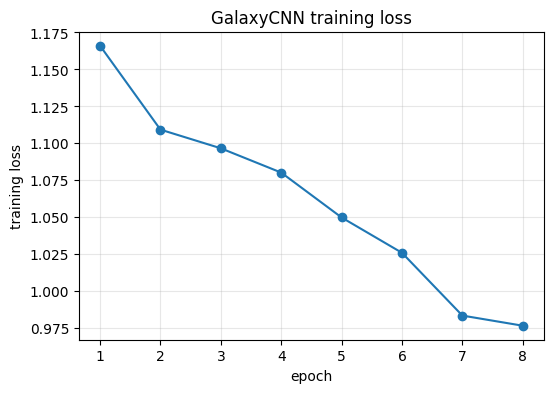

In [22]:
# TODO: plt.plot(train_losses, marker='o'); label axes; title 'Training loss'; plt.show()
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("training loss")
plt.title("GalaxyCNN training loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 7 (stretch) - Save Part 1's weights for Part 2

Optional but handy: save the trained weights so the Part-2 notebook can load them instead of re-training. Save to Drive so they survive a runtime recycle. (Saving/loading is covered fully in [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).)

In [23]:
# TODO (optional): torch.save(model.state_dict(), 'galaxy_model.pth'); print('saved')
from google.colab import drive; drive.mount('/content/drive')
torch.save(model.state_dict(), '/content/drive/MyDrive/galaxy_model.pth')

Mounted at /content/drive


## Reflection *(write 2-3 sentences each)*

1. Your CNN's parameter count - where do most of the weights live, and why is that different from the Week-2 MLP?
2. Describe the shape of your training-loss curve. What would it mean if the loss never fell? If it went to `nan`?
3. Low training loss is necessary but not sufficient. What does Part 2 add to check the model is actually good?

Answer 1:Almost all weights sit in the first Linear(8192, 128) of the head (~1.05M); the two conv layers together are only ~5k. Unlike the Week-2 MLP, the CNN's first layer is a cheap convolution that sees the whole image with shared kernels, so the model is far more parameter-efficient relative to the spatial work it does.

Answer 2:It should start near ln(num_classes) and fall steadily, with small wiggles. A flat curve from the start usually means a missing zero_grad, a tiny learning rate, or model/data on different devices; a nan usually means the LR is too high, labels aren't long, or inputs aren't normalised.

Answer 3:Low training loss can just mean memorisation. Part 2 evaluates on held-out validation/test data, plots train-vs-val curves to spot overfitting, and builds a confusion matrix to see which galaxy types the model confuses.